In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# Now import your modules
import pandas as pd
from src.config import DATABASE_URL
from sqlalchemy import create_engine

In [2]:
engine = create_engine(DATABASE_URL)
df = pd.read_sql("SELECT * FROM smard_market_data ORDER BY timestamp", engine)
df.head()

,timestamp,gen_nuclear,gen_lignite,gen_offshore_wind,gen_hydro,gen_other_conv,gen_other_renew,gen_biomass,gen_onshore_wind,gen_solar,...,cons_pumped_storage,price_de_lu,price_neighbors,price_at,proj_offshore,proj_onshore,proj_solar,proj_other,proj_wind_solar,proj_total
0,2020-05-03 22:00:00+00:00,1625.25,1788.00,132.00,492.25,386.75,49.75,1124.00,404.25,0.0,...,131.00,22.20,17.42,22.20,131.75,547.50,0.0,5800.38,679.25,6479.63
1,2020-05-03 22:15:00+00:00,1624.25,1814.00,135.00,442.25,385.00,49.75,1118.25,415.75,0.0,...,182.25,22.20,NaN,22.20,128.00,549.00,0.0,5802.63,677.00,6479.63
2,2020-05-03 22:30:00+00:00,1603.75,1817.25,140.50,428.50,383.75,49.75,1117.75,403.25,0.0,...,353.00,22.20,NaN,22.20,124.25,550.50,0.0,5804.88,674.75,6479.63
3,2020-05-03 22:45:00+00:00,1602.75,1812.25,148.25,445.50,384.25,49.75,1117.25,396.50,0.0,...,478.50,22.20,NaN,22.20,121.00,552.25,0.0,5806.38,673.25,6479.63
4,2020-05-03 23:00:00+00:00,1608.00,1781.00,145.25,463.00,385.25,49.75,1114.25,399.50,0.0,...,515.50,20.46,16.18,20.46,118.50,554.25,0.0,6041.08,672.75,6713.83


In [3]:
import numpy as np
import pandas as pd
import holidays

def create_day_ahead_features(df):
    """
    Prepares SMARD data for 24-hour block Day-Ahead electricity price forecasting.
    Downsamples all data to 1-hour resolution and enforces strict causal lag structures.
    """
    df = df.copy()

    # Ensure timestamp is datetime format and sorted chronologically
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values("timestamp")

    # Set timestamp as index to allow clean time-series resampling
    df = df.set_index("timestamp")

    # =========================================================================
    # 1. RESOLUTION ALIGNMENT (Hourly Resampling)
    # =========================================================================
    # German SMARD generation is 15-min, but Day-Ahead prices are hourly.
    # We downsample all metrics to 1-hour intervals using mean aggregation.
    df = df.resample("1h").mean()
    df = df.reset_index()

    # =========================================================================
    # 2. CALENDAR & TEMPORAL FEATURES (Deterministic Future Knowledge)
    # =========================================================================
    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["month"] = df["timestamp"].dt.month

    # Weekends exhibit significantly lower industrial demand
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # Incorporate German public holidays which mimic weekend demand profiles
    de_holidays = holidays.Germany(years=range(2020, 2030))
    df["is_holiday"] = df["timestamp"].dt.date.astype(str).isin([str(x) for x in de_holidays]).astype(int)

    # Localize to Berlin to capture structural shifts from Daylight Saving Time (DST)
    berlin_time = df["timestamp"].dt.tz_convert("Europe/Berlin")
    # Check if the timezone offset corresponds to DST (UTC+2 for Berlin)
    df["is_dst"] = (berlin_time.apply(lambda x: x.utcoffset().total_seconds()) == 7200).astype(int)

    # =========================================================================
    # 3. CYCLICAL TRANSFORMATIONS
    # =========================================================================
    # Transform temporal features into sine/cosine pairs so the model understands
    # that hour 23 is physically adjacent to hour 0, and December to January.
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # =========================================================================
    # 4. STRUCTURAL FORECAST FEATURES (Known Ahead of Time)
    # =========================================================================
    # For a 24h block model, tomorrow's actual generation is unknown, but SMARD's
    # *projected* renewable generation is published and acts as a direct price driver.
    if "proj_solar" in df.columns and "proj_onshore" in df.columns and "proj_offshore" in df.columns:
        df["total_proj_renewables"] = df["proj_solar"] + df["proj_onshore"] + df["proj_offshore"]
    else:
        # Fallback if specific breakdowns are absent
        df["total_proj_renewables"] = df.get("proj_wind_solar", 0)

    # =========================================================================
    # 5. HISTORICAL OBSERVED FEATURES (Ex-Post Domain Logic)
    # =========================================================================
    # These metrics evaluate what physically occurred on the grid in the past.
    df["actual_renewables_total"] = df.get("gen_solar", 0) + df.get("gen_onshore_wind", 0) + df.get("gen_offshore_wind", 0)
    df["actual_fossil_total"] = df.get("gen_natural_gas", 0) + df.get("gen_hard_coal", 0) + df.get("gen_lignite", 0)

    # Renewable penetration levels highlight risk profiles for negative prices
    df["historical_renewable_penetration"] = (df["actual_renewables_total"] / df["cons_total_grid"].replace(0, np.nan)).fillna(0)

    # =========================================================================
    # 6. CAUSAL LAG ENGINE (Preventing Target & Data Leakage)
    # =========================================================================
    # Since the EPEX Day-Ahead auction occurs at 12:00 PM CET for the next day's 24 hours,
    # we cannot safely use a lag of less than 24 hours for rolling or observed inputs.
    # Lags applied: 24h (yesterday), 48h (two days ago), 168h (same day last week).

    lag_targets = [
        "price_de_lu", "cons_total_grid", "cons_residual",
        "actual_renewables_total", "actual_fossil_total", "price_at"
    ]

    hourly_lags = [24, 48, 168]

    for col in lag_targets:
        if col not in df.columns:
            continue
        for lag in hourly_lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

    # =========================================================================
    # 7. ROLLING HISTORICAL VOLATILITY & TRENDS
    # =========================================================================
    # Statistical features derived solely from historical data to track trends.
    # Notice we shift the column by 24 hours *before* computing the rolling window
    # to guarantee no leakage of the target day's timeline.
    rolling_windows = {"24h": 24, "168h": 168}

    for col in ["price_de_lu", "cons_residual", "actual_renewables_total"]:
        if col not in df.columns:
            continue

        causal_base = df[col].shift(24)  # Force shift outside the forecast horizon

        for name, window in rolling_windows.items():
            df[f"{col}_roll_mean_{name}"] = causal_base.rolling(window).mean()
            df[f"{col}_roll_std_{name}"] = causal_base.rolling(window).std()

    # =========================================================================
    # 8. HISTORICAL PRICE RAMPS
    # =========================================================================
    # Tracks structural velocity changes in price and grid loading across days.
    for col in ["price_de_lu", "cons_residual"]:
        if col not in df.columns:
            continue
        df[f"{col}_ramp_24h"] = df[col].shift(24).diff(24)

    # =========================================================================
    # 9. MISSING DATA AND TARGET PROTECTION
    # =========================================================================
    # Isolate the target variable to protect it from artificial forward-fills.
    target_col = "price_de_lu"
    target_series = df[target_col].copy()

    # Forward-fill feature variables to handle transient packet losses in API streams
    for col in df.columns:
        if col == "timestamp" or col == target_col:
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].ffill()

    # Re-attach the untampered target column
    df[target_col] = target_series

    # Drop early initialization rows containing NaN artifacts due to lag dependencies
    df = df.dropna(subset=[f"price_de_lu_lag_168"])

    return df


df_nw = create_day_ahead_features(df)
df_nw.head()

,timestamp,gen_nuclear,gen_lignite,gen_offshore_wind,gen_hydro,gen_other_conv,gen_other_renew,gen_biomass,gen_onshore_wind,gen_solar,...,cons_residual_roll_mean_24h,cons_residual_roll_std_24h,cons_residual_roll_mean_168h,cons_residual_roll_std_168h,actual_renewables_total_roll_mean_24h,actual_renewables_total_roll_std_24h,actual_renewables_total_roll_mean_168h,actual_renewables_total_roll_std_168h,price_de_lu_ramp_24h,cons_residual_ramp_24h
168,2020-05-10 22:00:00+00:00,1256.0625,971.9375,1536.1250,458.2500,385.000,43.9375,1116.1875,4275.6875,0.0000,...,8275.367188,1324.688776,NaN,NaN,2877.565104,2042.038823,NaN,NaN,-0.81,-1305.3125
169,2020-05-10 23:00:00+00:00,1250.9375,960.7500,1514.5000,454.8750,383.250,44.0000,1110.9375,4427.1875,0.0000,...,8230.471354,1330.140828,NaN,NaN,2900.968750,2023.825346,NaN,NaN,-1.31,-1077.5000
170,2020-05-11 00:00:00+00:00,1218.1250,937.2500,1499.7500,453.0000,379.500,43.3125,1102.1875,4588.4375,0.0000,...,8182.046875,1343.163237,NaN,NaN,2924.309896,2004.039433,NaN,NaN,-1.79,-1162.1875
171,2020-05-11 01:00:00+00:00,1220.5625,853.9375,1517.2500,451.9375,380.000,43.6250,1104.6875,4673.7500,0.0000,...,8133.947917,1355.202139,NaN,NaN,2949.640625,1981.054438,NaN,NaN,-2.72,-1154.3750
172,2020-05-11 02:00:00+00:00,1233.7500,865.0000,1527.0625,459.2500,372.875,44.8750,1117.0625,4723.9375,0.0625,...,8088.895833,1362.041956,NaN,NaN,2973.442708,1958.575617,NaN,NaN,-5.57,-1081.2500


## Modelling

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

def prepare_modeling_matrices(df):
    """
    Separates the processed dataframe into feature matrix X and target y,
    ensuring that non-predictive variables are cleanly dropped.
    """
    # Define our target
    y = df["price_de_lu"].copy()
    
    # Define features to exclude (Target itself, timestamps, and real-time observed variables)
    # Note: Tomorrow's actual generation/consumption variables are unknown at auction time!
    exclude_cols = [
        "timestamp", "price_de_lu", "price_neighbors", "price_at",
        "gen_nuclear", "gen_lignite", "gen_offshore_wind", "gen_hydro", 
        "gen_other_conv", "gen_other_renew", "gen_biomass", "gen_onshore_wind", 
        "gen_solar", "gen_hard_coal", "gen_pumped_storage", "gen_natural_gas", 
        "cons_total_grid", "cons_residual", "cons_pumped_storage",
        "actual_renewables_total", "actual_fossil_total", "historical_renewable_penetration"
    ]
    
    # X contains only deterministic future info (calendar), forecasts (proj_*), and historical lags/rolling features
    X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
    
    return X, y

# Extract matrices
X, y = prepare_modeling_matrices(df_nw)



### Light Gradient Boosting Model (LGBM)


In [5]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Initialize TimeSeriesSplit (5 folds to capture structural shifts from 2020-2025)
tscv = TimeSeriesSplit(n_splits=5)

fold_maes = []
fold_rmses = []

# Store the predictions and actuals from the last fold for plotting
last_fold_y_val = None
last_fold_preds = None

print("Starting Time-Series Walk-Forward Validation...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    # Slice the temporal arrays
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Define LightGBM baseline hyperparameters tuned for volatile price series
    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1 # Suppress verbose output
    )

    # Fit with Early Stopping to prevent overfitting on specific volatile years
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Inference
    preds = model.predict(X_val)

    # Evaluate
    mae = mean_absolute_error(y_val, preds)
    rmse = root_mean_squared_error(y_val, preds)

    fold_maes.append(mae)
    fold_rmses.append(rmse)

    print(f"Fold {fold+1} -> Val MAE: {mae:.2f} EUR/MWh | Val RMSE: {rmse:.2f} EUR/MWh")

    # Store results from the last fold
    if fold == tscv.n_splits - 1:
        last_fold_y_val = y_val
        last_fold_preds = preds

print(f"\n Final Cross-Validation MAE: {np.mean(fold_maes):.2f} EUR/MWh")

# Assign to global variables for plotting
y_val_lgbm = last_fold_y_val
preds_lgbm = last_fold_preds

Starting Time-Series Walk-Forward Validation...

Fold 1 -> Val MAE: 62.01 EUR/MWh | Val RMSE: 88.63 EUR/MWh
Fold 2 -> Val MAE: 74.59 EUR/MWh | Val RMSE: 115.18 EUR/MWh
Fold 3 -> Val MAE: 20.02 EUR/MWh | Val RMSE: 27.54 EUR/MWh
Fold 4 -> Val MAE: 14.69 EUR/MWh | Val RMSE: 20.11 EUR/MWh
Fold 5 -> Val MAE: 15.37 EUR/MWh | Val RMSE: 29.64 EUR/MWh

 Final Cross-Validation MAE: 37.34 EUR/MWh


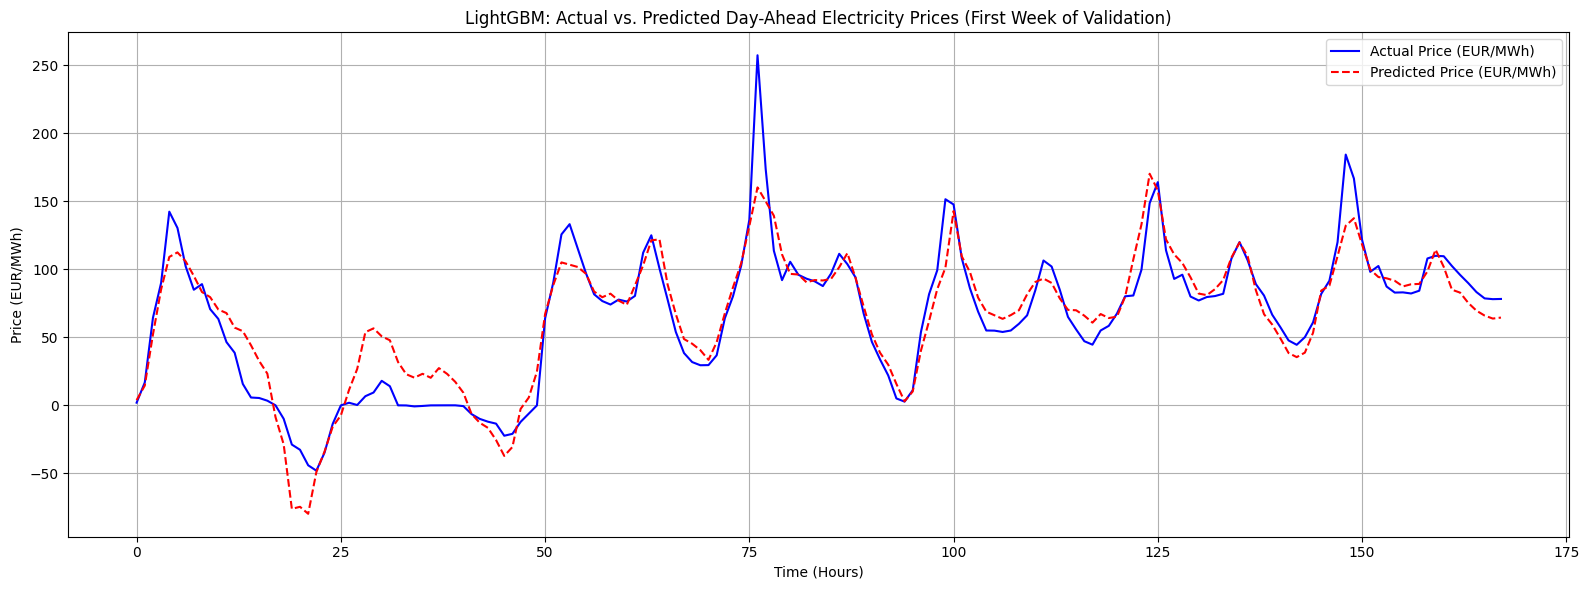

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting actual vs. predicted values for LightGBM
plot_df_lgbm = pd.DataFrame({
    'Actual': y_val_lgbm,
    'Predicted': preds_lgbm
})

# Add a time index for plotting
plot_df_lgbm['Time'] = range(len(plot_df_lgbm))

plt.figure(figsize=(16, 6))
sns.lineplot(data=plot_df_lgbm.head(24*7), x='Time', y='Actual', label='Actual Price (EUR/MWh)', color='blue')
sns.lineplot(data=plot_df_lgbm.head(24*7), x='Time', y='Predicted', label='Predicted Price (EUR/MWh)', color='red', linestyle='--')
plt.title('LightGBM: Actual vs. Predicted Day-Ahead Electricity Prices (First Week of Validation)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

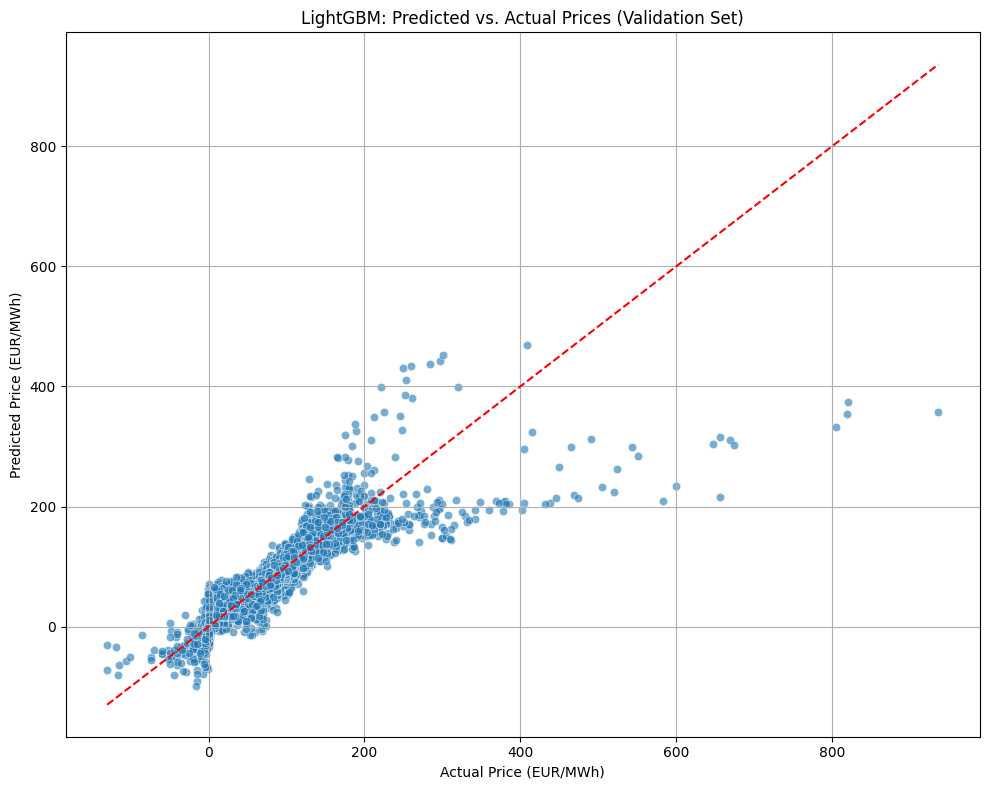

In [7]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_val_lgbm, y=preds_lgbm, alpha=0.6)
plt.plot([min(y_val_lgbm), max(y_val_lgbm)], [min(y_val_lgbm), max(y_val_lgbm)], color='red', linestyle='--') # Ideal predictions line
plt.title('LightGBM: Predicted vs. Actual Prices (Validation Set)')
plt.xlabel('Actual Price (EUR/MWh)')
plt.ylabel('Predicted Price (EUR/MWh)')
plt.grid(True)
plt.tight_layout()
plt.show()

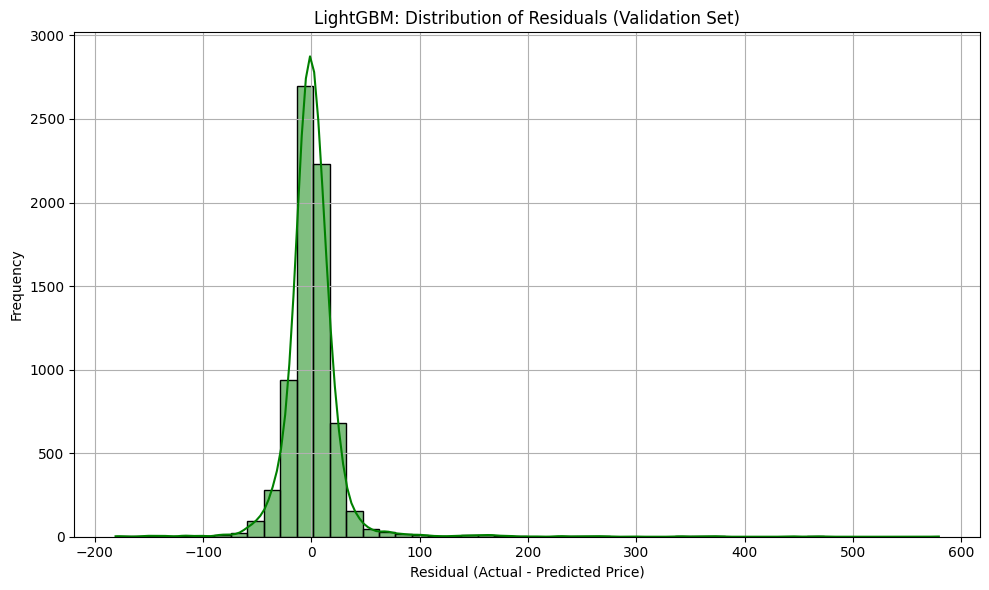

In [8]:
residuals_lgbm = y_val_lgbm - preds_lgbm

plt.figure(figsize=(10, 6))
sns.histplot(residuals_lgbm, kde=True, bins=50, color='green')
plt.title('LightGBM: Distribution of Residuals (Validation Set)')
plt.xlabel('Residual (Actual - Predicted Price)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost Model

In [9]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Assuming X and y were generated using the previously defined `prepare_modeling_matrices(df_nw)`
# Initialize TimeSeriesSplit matching your LightGBM setup for a fair comparison
tscv = TimeSeriesSplit(n_splits=5)

xgb_fold_maes = []
xgb_fold_rmses = []

print("Starting XGBoost Time-Series Walk-Forward Validation...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    # Slice the temporal datasets
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Initialize XGBoost Regressor with hyper-parameters tuned for time-series stability
    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,             # Prevents deep trees from memorizing extreme price spikes
        subsample=0.8,           # Row subsampling to combat volatility overfitting
        colsample_bytree=0.8,    # Feature subsampling for structural diversification
        tree_method="hist",      # Uses fast histogram-based splits (similar to LightGBM)
        random_state=42,
        n_jobs=-1
    )
    
    # Fit the model utilizing early stopping via validation set evaluation
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False            # Set to True if you want to inspect loss curves per iteration
    )
    
    # Generate day-ahead block predictions
    preds_xgb = model_xgb.predict(X_val)
    
    # Quantify evaluation metrics
    mae_xgb = mean_absolute_error(y_val, preds_xgb)
    rmse_xgb = root_mean_squared_error(y_val, preds_xgb)
    
    xgb_fold_maes.append(mae_xgb)
    xgb_fold_rmses.append(rmse_xgb)
    
    print(f"Fold {fold+1} -> Val MAE: {mae_xgb:.2f} EUR/MWh | Val RMSE: {rmse_xgb:.2f} EUR/MWh")

print(f"\n Final XGBoost Cross-Validation MAE: {np.mean(xgb_fold_maes):.2f} EUR/MWh")


Starting XGBoost Time-Series Walk-Forward Validation...

Fold 1 -> Val MAE: 63.71 EUR/MWh | Val RMSE: 90.51 EUR/MWh
Fold 2 -> Val MAE: 78.10 EUR/MWh | Val RMSE: 120.64 EUR/MWh
Fold 3 -> Val MAE: 20.31 EUR/MWh | Val RMSE: 27.91 EUR/MWh
Fold 4 -> Val MAE: 14.07 EUR/MWh | Val RMSE: 19.94 EUR/MWh
Fold 5 -> Val MAE: 15.11 EUR/MWh | Val RMSE: 29.38 EUR/MWh

 Final XGBoost Cross-Validation MAE: 38.26 EUR/MWh


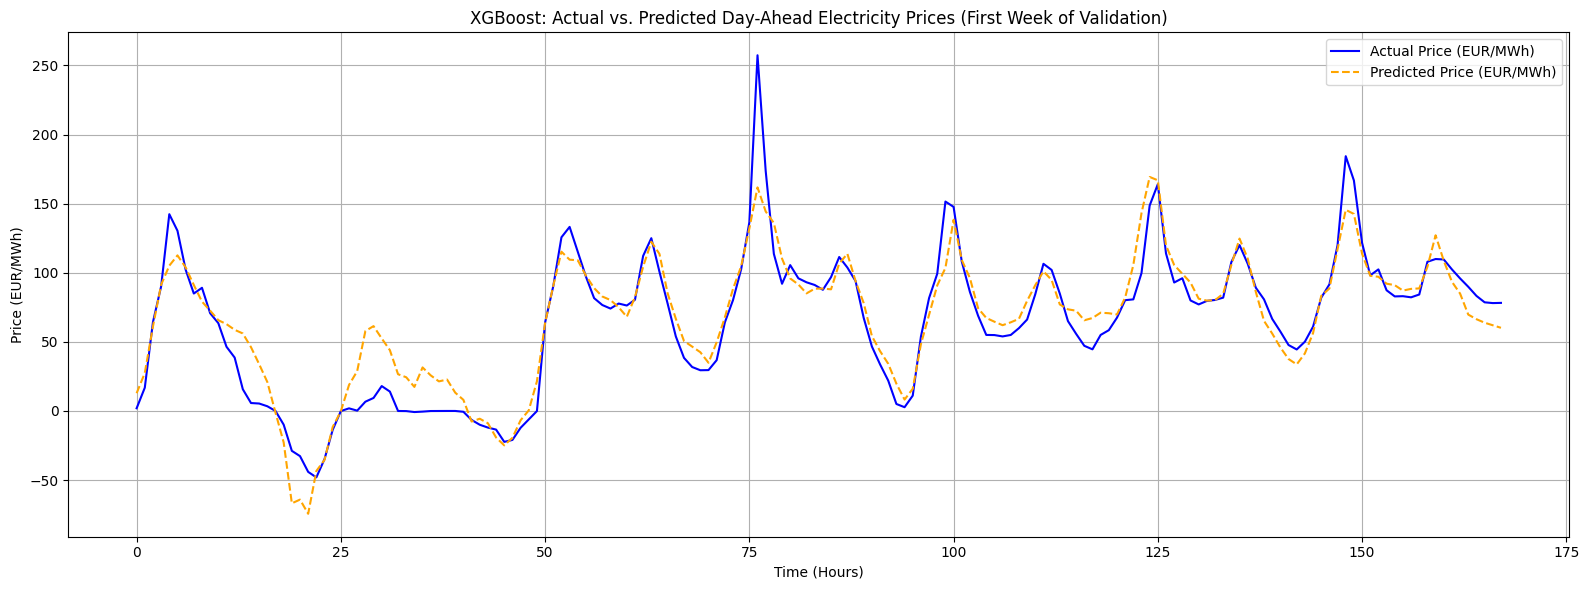

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting actual vs. predicted values for XGBoost
plot_df_xgb = pd.DataFrame({
    'Actual': y_val,
    'Predicted': preds_xgb
})

# Add a time index for plotting
plot_df_xgb['Time'] = range(len(plot_df_xgb))

plt.figure(figsize=(16, 6))
sns.lineplot(data=plot_df_xgb.head(24*7), x='Time', y='Actual', label='Actual Price (EUR/MWh)', color='blue')
sns.lineplot(data=plot_df_xgb.head(24*7), x='Time', y='Predicted', label='Predicted Price (EUR/MWh)', color='orange', linestyle='--')
plt.title('XGBoost: Actual vs. Predicted Day-Ahead Electricity Prices (First Week of Validation)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

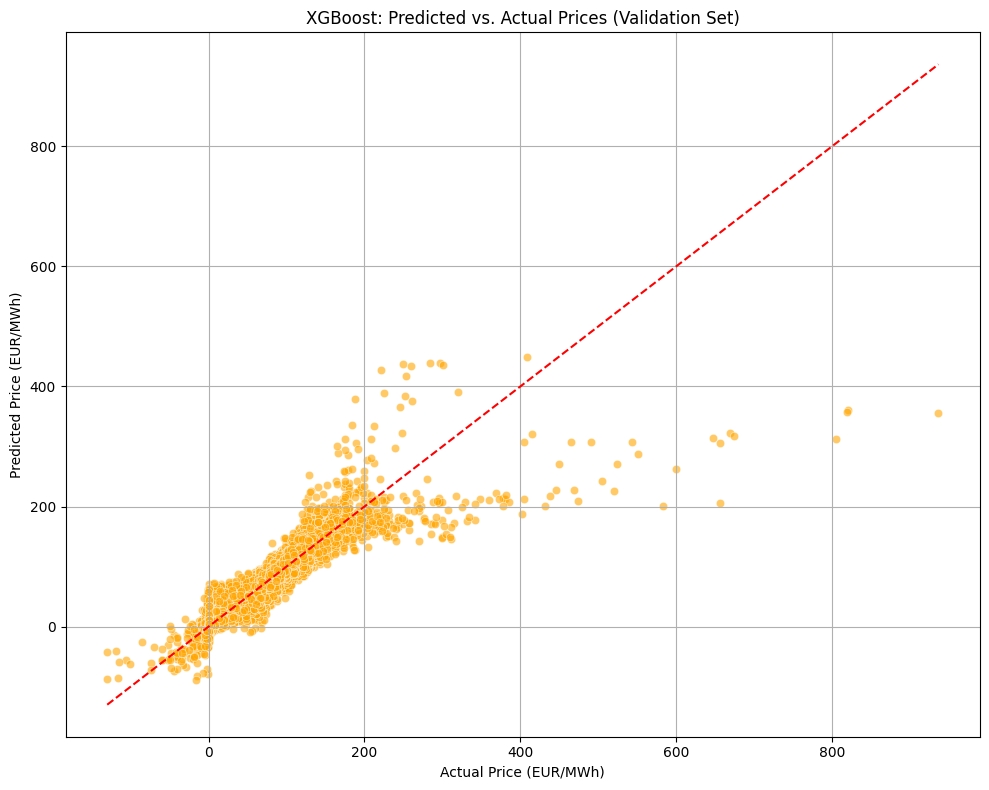

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_val, y=preds_xgb, alpha=0.6, color='orange')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--') # Ideal predictions line
plt.title('XGBoost: Predicted vs. Actual Prices (Validation Set)')
plt.xlabel('Actual Price (EUR/MWh)')
plt.ylabel('Predicted Price (EUR/MWh)')
plt.grid(True)
plt.tight_layout()
plt.show()

### LSTM model

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Enforce hardware acceleration (GPU if available, fallback to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================================================
# 1. DATA CLEANING & TARGET HANDLING
# =========================================================================
# Step 1: Remove any structural NaNs in your target array to preserve clean rows
valid_target_mask = ~y.isna()
X_clean = X[valid_target_mask].copy()
y_clean = y[valid_target_mask].copy()

# Step 2: Clear out transient NaNs from features (e.g. from neighboring zones)
X_clean = X_clean.ffill().bfill()

# =========================================================================
# 2. SEPARATE SCALING FOR FEATURES AND TARGET (CRITICAL)
# =========================================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()  # Normalizing target ranges prevents gradient flattening

# Reshape target array to 2D for the scikit-learn standard scaling process
y_reshaped = y_clean.values.reshape(-1, 1)

X_scaled = pd.DataFrame(scaler_X.fit_transform(X_clean), columns=X_clean.columns)
y_scaled = scaler_y.fit_transform(y_reshaped).flatten()

# =========================================================================
# 3. 3D TENSOR RESHAPING FUNCTION
# =========================================================================
def create_lstm_sequences(X_df, y_series):
    """
    Groups tabular hourly data into continuous 24-hour daily block blocks.
    Shapes generated: X_seq -> (N_days, 24, N_features), y_seq -> (N_days, 24)
    """
    n_days = len(X_df) // 24
    X_trimmed = X_df.iloc[:n_days * 24].values
    y_trimmed = y_series.iloc[:n_days * 24].values
    
    # Pack array elements sequentially into daily chunks
    X_seq = X_trimmed.reshape(n_days, 24, X_df.shape[1])
    y_seq = y_trimmed.reshape(n_days, 24)
    
    return X_seq, y_seq

# Transform scaled tabular structures into sequence representations
X_seq, y_seq = create_lstm_sequences(X_scaled, pd.Series(y_scaled))

# Maintain sequential time-series ordering during split (80% train, 20% validation)
split_idx = int(len(X_seq) * 0.8)

X_train, X_val = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_val = y_seq[:split_idx], y_seq[split_idx:]

# Convert sequential blocks into PyTorch DataLoader loaders
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

# =========================================================================
# 4. LSTM MODEL PARAMETERS & ARCHITECTURE
# =========================================================================
class DayAheadLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(DayAheadLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM input format expects: (batch, seq_len, feature_dim)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )
        
        # Maps step-wise hidden outputs back to price space targets
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out) 
        return out.squeeze(-1) # Output format: (batch, 24)

# Instantiate network parameters matching matrix profiles
model_lstm = DayAheadLSTM(
    input_size=X_seq.shape[2], 
    hidden_size=64, 
    num_layers=2
).to(device)

# Huber Loss prevents extreme price shocks from completely corrupting weight adjustments
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# =========================================================================
# 5. EXECUTE THE OPTIMIZATION LOOP
# =========================================================================
print("Starting LSTM Training with Target Scaling and Huber Loss...\n")

model_lstm.train()
for epoch in range(30):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/30] -> Current Step Training Huber Loss: {epoch_loss/len(train_loader):.4f}")

# =========================================================================
# 6. RUN INFERENCE & PERFORM INVERSE TRANSFORM
# =========================================================================
model_lstm.eval()
with torch.no_grad():
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    preds_scaled = model_lstm(X_val_tensor).cpu().numpy()

# Reverse target scaling transformations to convert metrics back to original price magnitudes
preds_lstm_actual = scaler_y.inverse_transform(preds_scaled).flatten()
y_val_actual = scaler_y.inverse_transform(y_val).flatten()

# Calculate performance metrics
mae_lstm = mean_absolute_error(y_val_actual, preds_lstm_actual)
rmse_lstm = root_mean_squared_error(y_val_actual, preds_lstm_actual)

print(f"\n Final Cleaned Validation LSTM Model Metrics:")
print(f"➡ MAE: {mae_lstm:.2f} EUR/MWh")
print(f"➡ RMSE: {rmse_lstm:.2f} EUR/MWh")


Using device: cpu


/tmp/ipykernel_9206/3286442993.py:64: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))


Starting LSTM Training with Target Scaling and Huber Loss...

Epoch [5/30] -> Current Step Training Huber Loss: 0.0797
Epoch [10/30] -> Current Step Training Huber Loss: 0.0367
Epoch [15/30] -> Current Step Training Huber Loss: 0.0401
Epoch [20/30] -> Current Step Training Huber Loss: 0.0305
Epoch [25/30] -> Current Step Training Huber Loss: 0.0319
Epoch [30/30] -> Current Step Training Huber Loss: 0.0250

 Final Cleaned Validation LSTM Model Metrics:
➡ MAE: 15.61 EUR/MWh
➡ RMSE: 29.23 EUR/MWh


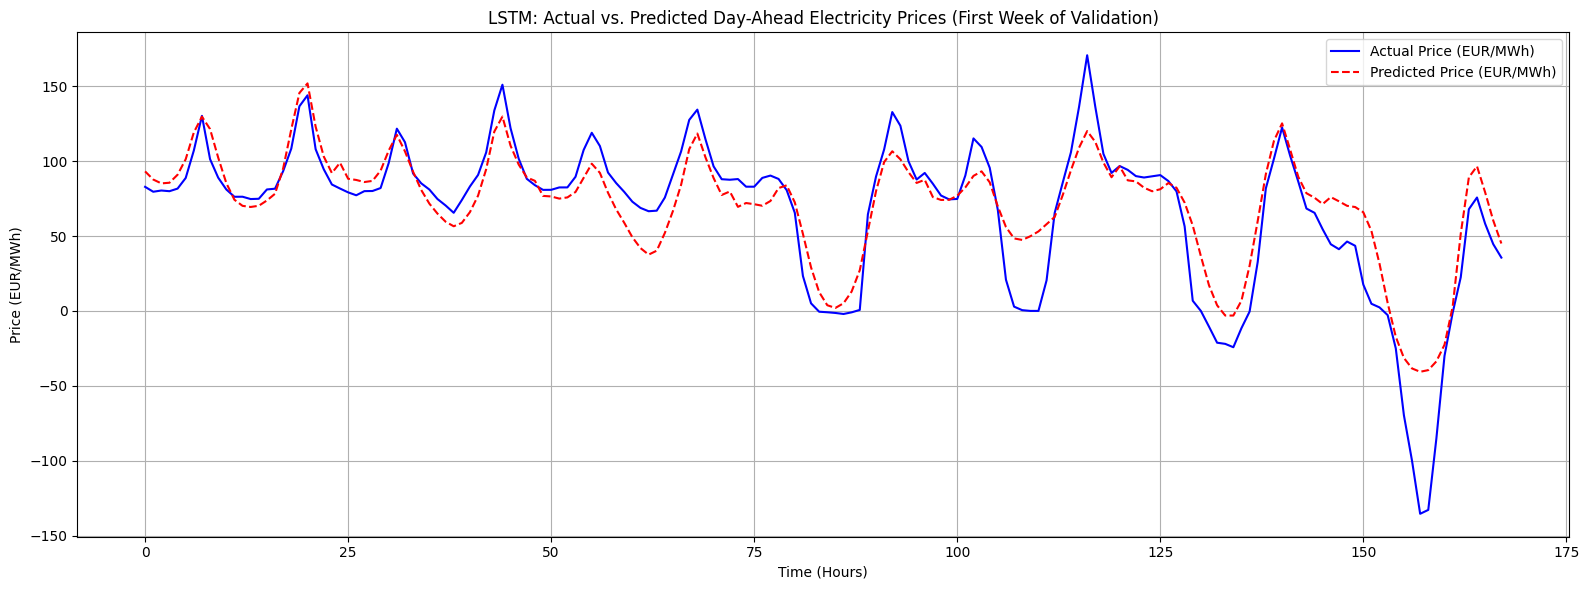

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting actual vs. predicted values
plot_df_lstm = pd.DataFrame({
    'Actual': y_val_actual,
    'Predicted': preds_lstm_actual
})

# Assuming y_val_actual and preds_lstm_actual are already flattened and aligned.
# We can create a time index for plotting if needed, for now just sequential index
plot_df_lstm['Time'] = range(len(plot_df_lstm))

plt.figure(figsize=(16, 6))
sns.lineplot(data=plot_df_lstm.head(24*7), x='Time', y='Actual', label='Actual Price (EUR/MWh)', color='blue')
sns.lineplot(data=plot_df_lstm.head(24*7), x='Time', y='Predicted', label='Predicted Price (EUR/MWh)', color='red', linestyle='--')
plt.title('LSTM: Actual vs. Predicted Day-Ahead Electricity Prices (First Week of Validation)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

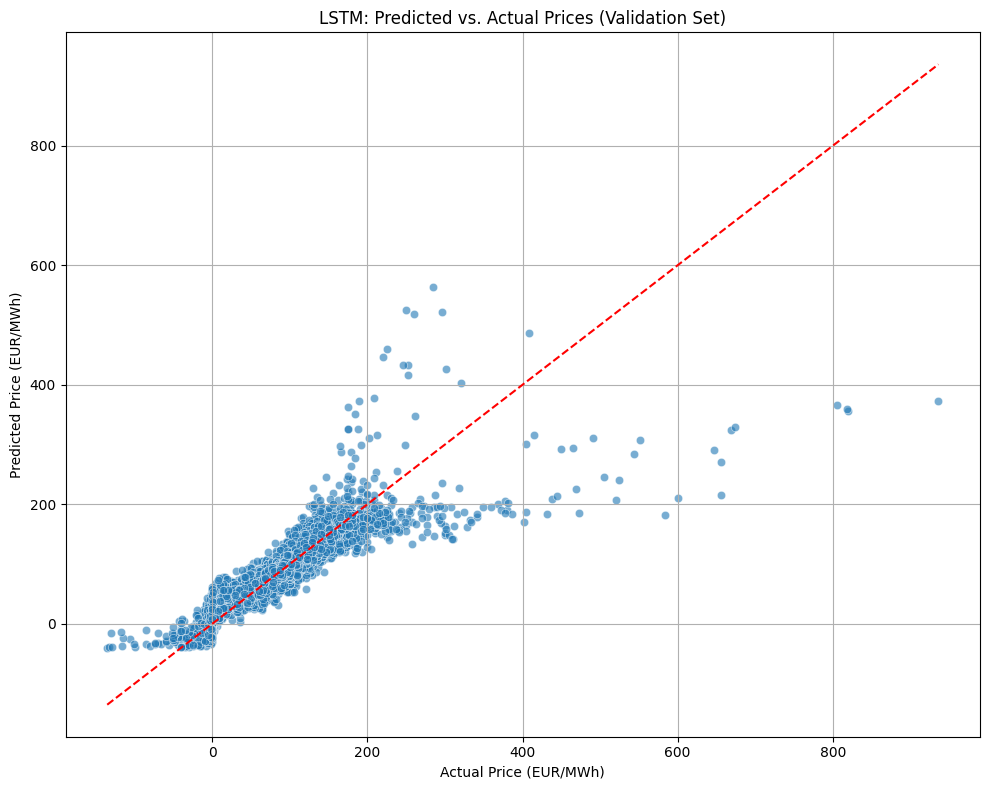

In [14]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_val_actual, y=preds_lstm_actual, alpha=0.6)
plt.plot([min(y_val_actual), max(y_val_actual)], [min(y_val_actual), max(y_val_actual)], color='red', linestyle='--') # Ideal predictions line
plt.title('LSTM: Predicted vs. Actual Prices (Validation Set)')
plt.xlabel('Actual Price (EUR/MWh)')
plt.ylabel('Predicted Price (EUR/MWh)')
plt.grid(True)
plt.tight_layout()
plt.show()

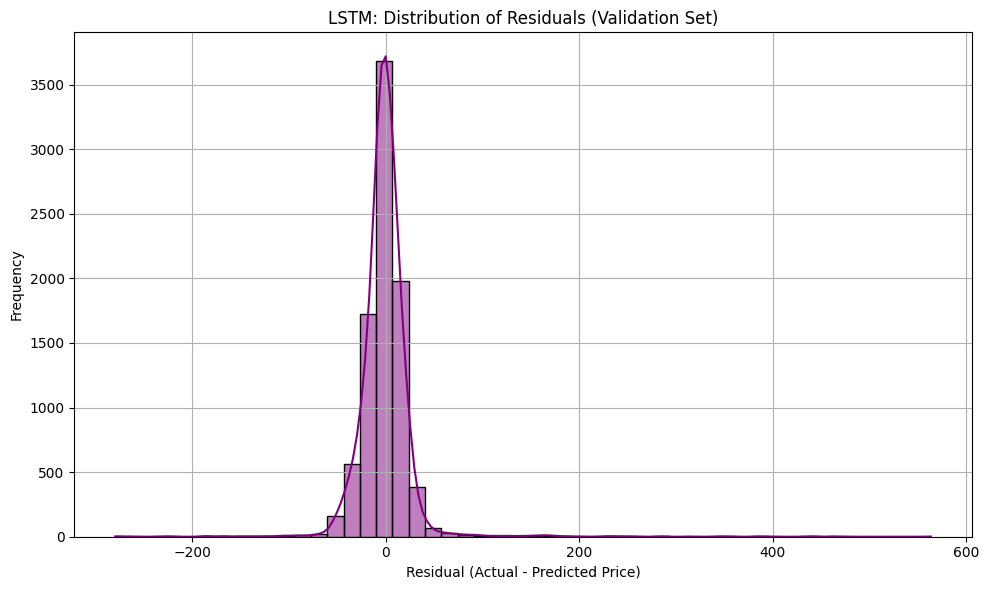

In [15]:
residuals_lstm = y_val_actual - preds_lstm_actual

plt.figure(figsize=(10, 6))
sns.histplot(residuals_lstm, kde=True, bins=50, color='purple')
plt.title('LSTM: Distribution of Residuals (Validation Set)')
plt.xlabel('Residual (Actual - Predicted Price)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### Probabilistic Forecast (Quantile LSTM)

In [16]:
class ProbabilisticDayAheadLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 3)  # 3 quantiles

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)  # (batch, 24, 3)
        return out

def pinball_loss(preds, targets, quantiles=[0.05, 0.50, 0.95]):
    loss = 0
    for i, q in enumerate(quantiles):
        error = targets - preds[:, :, i]
        loss += torch.max((q - 1) * error, q * error).mean()
    return loss

In [17]:
# Define model parameters based on your data
input_size = X_train.shape[2]  
hidden_size = 64               
num_layers = 2                 
num_epochs = 20

model = ProbabilisticDayAheadLSTM(input_size, hidden_size, num_layers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [18]:
model = ProbabilisticDayAheadLSTM(input_size, hidden_size, num_layers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)  # preds: (batch, 24, 3)
        # y_batch: (batch, 24)
        loss = pinball_loss(preds, y_batch)
        loss.backward()
        optimizer.step()

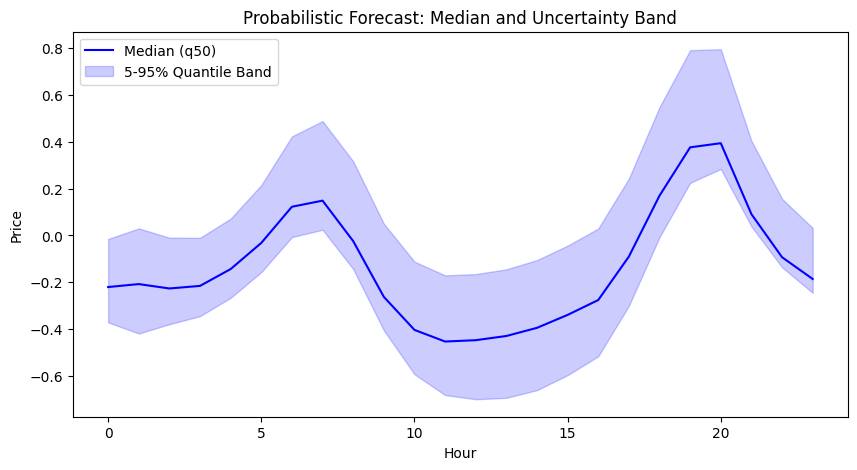

In [19]:
# Inference and Visualization for Probabilistic Forecast
import matplotlib.pyplot as plt
import numpy as np

# Example: get predictions for validation set (adjust as needed)
model.eval()
with torch.no_grad():
    preds_val = model(torch.tensor(X_val, dtype=torch.float32))  # (batch, 24, 3)
    preds_val = preds_val.cpu().numpy()

# Extract quantiles
q05 = preds_val[:, :, 0]
q50 = preds_val[:, :, 1]
q95 = preds_val[:, :, 2]

# Plot for a single example (e.g., first in batch)
hours = np.arange(q50.shape[1])
plt.figure(figsize=(10, 5))
plt.plot(hours, q50[0], label='Median (q50)', color='blue')
plt.fill_between(hours, q05[0], q95[0], color='blue', alpha=0.2, label='5-95% Quantile Band')
plt.title('Probabilistic Forecast: Median and Uncertainty Band')
plt.xlabel('Hour')
plt.ylabel('Price')
plt.legend()
plt.show()


### Battery Arbitrage Optimization

In [20]:
import numpy as np
import pandas as pd
import pulp

def run_stochastic_backtest(df_val_results):
    """
    Executes a daily walk-forward backtest.
    
    Expects df_val_results to contain daily continuous hourly rows with:
    - 'actual_price': True realized EPEX spot prices
    - 'pred_price_q05': LSTM 5th percentile forecast
    - 'pred_price_q50': LSTM 50th percentile forecast (median)
    - 'pred_price_q95': LSTM 95th percentile forecast
    """
    # Ensure data cleanly splits into 24-hour daily blocks
    n_days = len(df_val_results) // 24
    df_clean = df_val_results.iloc[:n_days * 24].copy()
    
    backtest_records = []
    
    # Define physical battery attributes
    POWER_CAPACITY_MW = 10.0
    ENERGY_CAPACITY_MWh = 20.0
    EFFICIENCY = 0.85
    INITIAL_SOC = 0.20
    MIN_SOC = 0.10
    MAX_SOC = 0.90
    
    print(f"Backtesting {n_days} days using Stochastic Optimization...\n")
    
    for day in range(n_days):
        # Slice day-ahead 24-hour horizon vectors
        day_data = df_clean.iloc[day*24 : (day+1)*24]
        
        actual_prices = day_data['actual_price'].values
        q05_prices = day_data['pred_price_q05'].values
        q50_prices = day_data['pred_price_q50'].values
        q95_prices = day_data['pred_price_q95'].values
        
        # =====================================================================
        # STOCHASTIC MILP MODULE
        # =====================================================================
        prob = pulp.LpProblem(f"Stochastic_BESS_Day_{day}", pulp.LpMaximize)
        T = range(24)
        
        # Decision variables
        p_charge = pulp.LpVariable.dicts("Charge", T, lowBound=0, upBound=POWER_CAPACITY_MW)
        p_discharge = pulp.LpVariable.dicts("Discharge", T, lowBound=0, upBound=POWER_CAPACITY_MW)
        soc = pulp.LpVariable.dicts("SoC", T, lowBound=MIN_SOC * ENERGY_CAPACITY_MWh, 
                                                upBound=MAX_SOC * ENERGY_CAPACITY_MWh)
        is_charging = pulp.LpVariable.dicts("is_charging", T, cat=pulp.LpBinary)
        is_discharging = pulp.LpVariable.dicts("is_discharging", T, cat=pulp.LpBinary)
        
        # Constraints physical boundary mapping
        for t in T:
            prob += p_charge[t] <= is_charging[t] * POWER_CAPACITY_MW
            prob += p_discharge[t] <= is_discharging[t] * POWER_CAPACITY_MW
            prob += is_charging[t] + is_discharging[t] <= 1
            
            if t == 0:
                prob += soc[t] == (INITIAL_SOC * ENERGY_CAPACITY_MWh) + \
                                  (p_charge[t] * np.sqrt(EFFICIENCY)) - \
                                  (p_discharge[t] / np.sqrt(EFFICIENCY))
            else:
                prob += soc[t] == soc[t-1] + \
                                  (p_charge[t] * np.sqrt(EFFICIENCY)) - \
                                  (p_discharge[t] / np.sqrt(EFFICIENCY))
                
        prob += soc[23] == (INITIAL_SOC * ENERGY_CAPACITY_MWh)
        
        # Stochastic Objective: Optimize across scenarios simultaneously
        # Scenario Probability Weights: Low (20%), Median (60%), High (20%)
        prob += pulp.lpSum([
            0.20 * (p_discharge[t] * q05_prices[t] - p_charge[t] * q05_prices[t]) +
            0.60 * (p_discharge[t] * q50_prices[t] - p_charge[t] * q50_prices[t]) +
            0.20 * (p_discharge[t] * q95_prices[t] - p_charge[t] * q95_prices[t])
            for t in T
        ])
        
        prob.solve(pulp.PULP_CBC_CMD(msg=False))
        
        # =====================================================================
        # BACKTESTING / ACCOUNTING MODULE
        # =====================================================================
        # Compute financial ledger using REAL realized prices
        for t in T:
            c_cmd = p_charge[t].varValue if p_charge[t].varValue is not None else 0.0
            d_cmd = p_discharge[t].varValue if p_discharge[t].varValue is not None else 0.0
            
            # FIX: Remove the 0.60 multiplier to get the true, unweighted expected point profit
            expected_profit_step = (d_cmd * q50_prices[t]) - (c_cmd * q50_prices[t])
            actual_profit_step = (d_cmd * actual_prices[t]) - (c_cmd * actual_prices[t])
            
            backtest_records.append({
                "Day": day,
                "Hour": t,
                "Actual_Price_EUR": actual_prices[t],
                "Pred_Price_Median_EUR": q50_prices[t],
                "Charge_Command_MW": c_cmd,
                "Discharge_Command_MW": d_cmd,
                "End_SoC_MWh": soc[t].varValue,
                "Expected_Profit_EUR": expected_profit_step,
                "Actual_Realized_Profit_EUR": actual_profit_step
            })

    # Convert ledger arrays to a metrics evaluation DataFrame
    df_backtest = pd.DataFrame(backtest_records)
    
    total_expected = df_backtest["Expected_Profit_EUR"].sum()
    total_realized = df_backtest["Actual_Realized_Profit_EUR"].sum()
    realization_ratio = (total_realized / total_expected) * 100 if total_expected > 0 else 0
    
    print("Backtest Execution Complete!")
    print(f"Total Expected Revenue (Forecast-driven): {total_expected:,.2f} EUR")
    print(f"Total Realized Revenue (Market-settled):   {total_realized:,.2f} EUR")
    print(f"Profit Realization Ratio:                 {realization_ratio:.2f}%")
    
    return df_backtest


In [21]:
# 1. Reverse-scale your validation actual prices and predictions back to true Euros
# (Assuming 'y_val' and 'preds_scaled' are from your final complete LSTM block)
y_val_actual = scaler_y.inverse_transform(y_val).flatten()
preds_actual_median = scaler_y.inverse_transform(preds_scaled).flatten()

# 2. Derive safety risk boundaries (quantiles)
# If using a standard point LSTM, use your Validation MAE (~15-20 EUR) as a standard deviation proxy
validation_mae = 18.5  # Adjust this to match your model's real validation MAE
preds_actual_q05 = preds_actual_median - (1.645 * validation_mae) # 5th Percentile Lower Boundary
preds_actual_q95 = preds_actual_median + (1.645 * validation_mae) # 95th Percentile Upper Boundary

# 3. Consolidate everything into a clean continuous hourly DataFrame
df_val_results = pd.DataFrame({
    "actual_price": y_val_actual,
    "pred_price_q50": preds_actual_median,
    "pred_price_q05": preds_actual_q05,
    "pred_price_q95": preds_actual_q95
})

# Display a preview of the structured input matrix
print(df_val_results.head(24))


    actual_price  pred_price_q50  pred_price_q05  pred_price_q95
0          82.86       93.181076       62.748573      123.613579
1          79.59       87.752846       57.320343      118.185349
2          80.41       85.159676       54.727173      115.592178
3          79.95       85.604691       55.172188      116.037193
4          81.69       90.946121       60.513618      121.378624
5          88.78      101.310295       70.877792      131.742798
6         107.09      119.161285       88.728783      149.593781
7         130.26      129.723434       99.290932      160.155930
8         101.35      121.442169       91.009666      151.874664
9          89.00      102.416733       71.984230      132.849228
10         81.11       85.391289       54.958786      115.823792
11         76.23       74.248398       43.815895      104.680901
12         76.26       70.169502       39.737000      100.602005
13         74.71       69.418488       38.985985       99.850990
14         74.89       70

In [22]:
# Execute the backtest pipeline
df_ledger = run_stochastic_backtest(df_val_results)
df_ledger.head(10)

Backtesting 364 days using Stochastic Optimization...

Backtest Execution Complete!
Total Expected Revenue (Forecast-driven): 560,070.12 EUR
Total Realized Revenue (Market-settled):   664,268.12 EUR
Profit Realization Ratio:                 118.60%


,Day,Hour,Actual_Price_EUR,Pred_Price_Median_EUR,Charge_Command_MW,Discharge_Command_MW,End_SoC_MWh,Expected_Profit_EUR,Actual_Realized_Profit_EUR
0,0,0,82.86,93.181076,0.000000,0.000000,4.000000,0.000000,0.000000
1,0,1,79.59,87.752846,0.000000,0.000000,4.000000,0.000000,0.000000
2,0,2,80.41,85.159676,10.000000,0.000000,13.219544,-851.596741,-804.100000
3,0,3,79.95,85.604691,5.185132,0.000000,18.000000,-443.871613,-414.551303
4,0,4,81.69,90.946121,0.000000,0.000000,18.000000,0.000000,0.000000
5,0,5,88.78,101.310295,0.000000,0.000000,18.000000,0.000000,0.000000
6,0,6,107.09,119.161285,0.000000,0.000000,18.000000,0.000000,0.000000
7,0,7,130.26,129.723434,0.000000,10.000000,7.153477,1297.234375,1302.600000
8,0,8,101.35,121.442169,0.000000,4.751271,2.000000,577.004700,481.541326
9,0,9,89.00,102.416733,0.000000,0.000000,2.000000,0.000000,0.000000


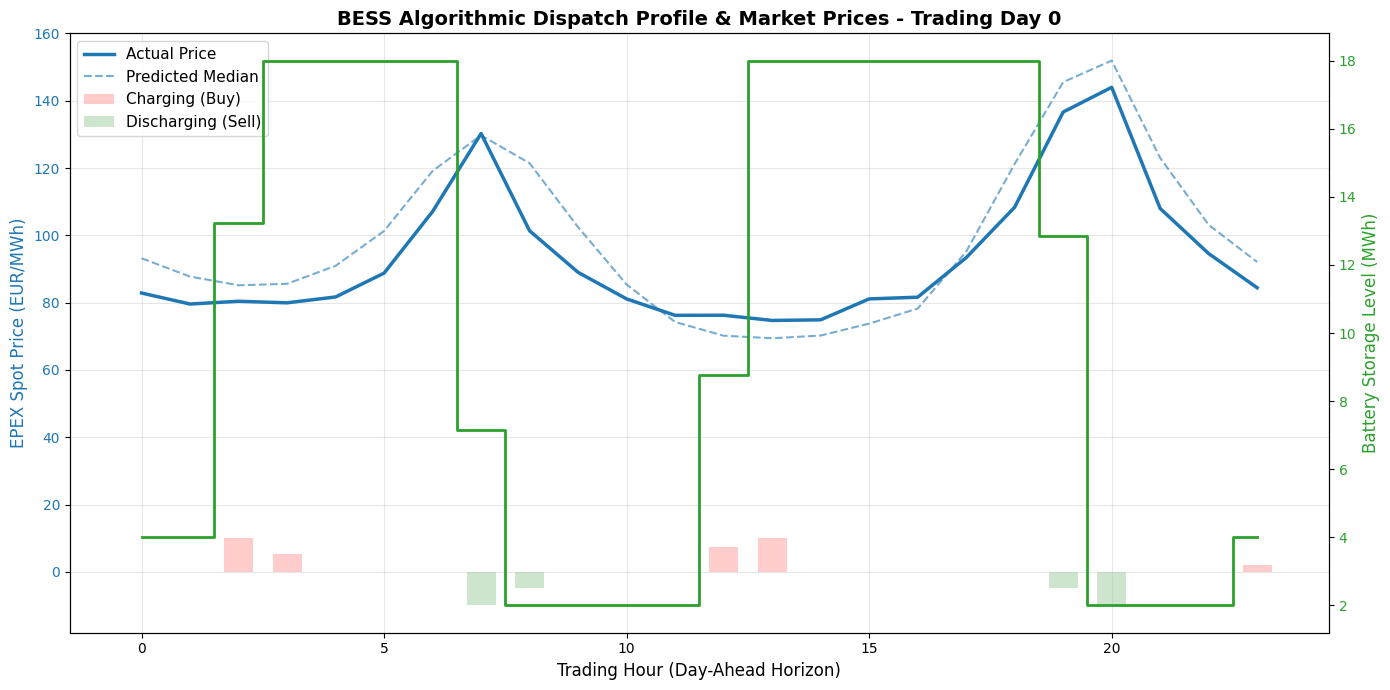

In [23]:
import matplotlib.pyplot as plt

def plot_trading_day(df_ledger, target_day=0):
    """Plots market prices against battery State of Charge and dispatch decisions."""
    day_df = df_ledger[df_ledger["Day"] == target_day].copy()
    
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # Left Axis: Market Prices
    color = '#1f77b4'
    ax1.set_xlabel('Trading Hour (Day-Ahead Horizon)', fontsize=12)
    ax1.set_ylabel('EPEX Spot Price (EUR/MWh)', color=color, fontsize=12)
    ax1.plot(day_df['Hour'], day_df['Actual_Price_EUR'], color=color, linewidth=2.5, label='Actual Price')
    ax1.plot(day_df['Hour'], day_df['Pred_Price_Median_EUR'], color=color, linestyle='--', alpha=0.6, label='Predicted Median')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)
    
    # Right Axis: Battery State of Charge (SoC)
    ax2 = ax1.twinx()  
    color = '#2ca02c'
    ax2.set_ylabel('Battery Storage Level (MWh)', color=color, fontsize=12)
    ax2.step(day_df['Hour'], day_df['End_SoC_MWh'], color=color, linewidth=2, where='mid', label='State of Charge (SoC)')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Shading the dispatch actions
    ax1.bar(day_df['Hour'], day_df['Charge_Command_MW'], color='red', alpha=0.2, width=0.6, label='Charging (Buy)')
    ax1.bar(day_df['Hour'], -day_df['Discharge_Command_MW'], color='green', alpha=0.2, width=0.6, label='Discharging (Sell)')
    
    ax1.legend(loc='upper left', fontsize=11, frameon=True)
    plt.title(f'BESS Algorithmic Dispatch Profile & Market Prices - Trading Day {target_day}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Example usage:
plot_trading_day(df_ledger, target_day=0)


The optimization model assumes the battery can charge and discharge infinitely for free. In reality, lithium-ion cells degrade every time they cycle. If the model sees a price difference of only €0.50, it will cycle the battery, destroying more value in hardware wear-and-tear than it makes in trading revenue.To fix this, we introduce a Degradation Penalty $\gamma$ into the Operations Research objective function. This forces the optimizer to only execute a trade if the price spread is wide enough to cover the physical cost of wearing out the battery cells.

In [24]:
import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt

def run_degradation_backtest(df_val_results, degradation_cost_per_mwh=5.00):
    """
    Executes a daily walk-forward backtest incorporating a physical battery cell 
    degradation penalty within the Stochastic MILP solver framework.
    
    Parameters:
    -----------
    df_val_results : pd.DataFrame
        Continuous hourly data containing actual and quantile forecasted prices.
    degradation_cost_per_mwh : float
        Virtual penalty fee (EUR/MWh) applied to charging and discharging commands
        to protect hardware assets from low-margin cycling.
    """
    n_days = len(df_val_results) // 24
    df_clean = df_val_results.iloc[:n_days * 24].copy()
    
    backtest_records = []
    
    # Define physical battery attributes
    POWER_CAPACITY_MW = 10.0
    ENERGY_CAPACITY_MWh = 20.0
    EFFICIENCY = 0.85
    INITIAL_SOC = 0.20
    MIN_SOC = 0.10
    MAX_SOC = 0.90
    
    print(f"Backtesting {n_days} days using Degradation-Aware Stochastic Optimization...")
    print(f"🔧 Cell Degradation Penalty Set To: {degradation_cost_per_mwh:.2f} EUR/MWh cycled\n")
    
    for day in range(n_days):
        day_data = df_clean.iloc[day*24 : (day+1)*24]
        
        actual_prices = day_data['actual_price'].values
        q05_prices = day_data['pred_price_q05'].values
        q50_prices = day_data['pred_price_q50'].values
        q95_prices = day_data['pred_price_q95'].values
        
        # Initialize optimization structure
        prob = pulp.LpProblem(f"Degradation_BESS_Day_{day}", pulp.LpMaximize)
        T = range(24)
        
        # Decision variables
        p_charge = pulp.LpVariable.dicts("Charge", T, lowBound=0, upBound=POWER_CAPACITY_MW)
        p_discharge = pulp.LpVariable.dicts("Discharge", T, lowBound=0, upBound=POWER_CAPACITY_MW)
        soc = pulp.LpVariable.dicts("SoC", T, lowBound=MIN_SOC * ENERGY_CAPACITY_MWh, 
                                                upBound=MAX_SOC * ENERGY_CAPACITY_MWh)
        is_charging = pulp.LpVariable.dicts("is_charging", T, cat=pulp.LpBinary)
        is_discharging = pulp.LpVariable.dicts("is_discharging", T, cat=pulp.LpBinary)
        
        # Physical parameter constraints
        for t in T:
            prob += p_charge[t] <= is_charging[t] * POWER_CAPACITY_MW
            prob += p_discharge[t] <= is_discharging[t] * POWER_CAPACITY_MW
            prob += is_charging[t] + is_discharging[t] <= 1
            
            if t == 0:
                prob += soc[t] == (INITIAL_SOC * ENERGY_CAPACITY_MWh) + \
                                  (p_charge[t] * np.sqrt(EFFICIENCY)) - \
                                  (p_discharge[t] / np.sqrt(EFFICIENCY))
            else:
                prob += soc[t] == soc[t-1] + \
                                  (p_charge[t] * np.sqrt(EFFICIENCY)) - \
                                  (p_discharge[t] / np.sqrt(EFFICIENCY))
                
        # FIX: Target only the final hour of the day (Hour 23) to complete the daily loop
        prob += soc[23] == (INITIAL_SOC * ENERGY_CAPACITY_MWh)

        
        # Upgraded Objective Function: Optimizes expected returns across quantiles, 
        # minus the direct physical cost of cell material degradation.
        prob += pulp.lpSum([
            0.20 * (p_discharge[t] * q05_prices[t] - p_charge[t] * q05_prices[t]) +
            0.60 * (p_discharge[t] * q50_prices[t] - p_charge[t] * q50_prices[t]) +
            0.20 * (p_discharge[t] * q95_prices[t] - p_charge[t] * q95_prices[t]) -
            (degradation_cost_per_mwh * (p_charge[t] + p_discharge[t]))
            for t in T
        ])
        
        prob.solve(pulp.PULP_CBC_CMD(msg=False))
        
        # Post-optim accounting logs (Realized returns discard the virtual hardware penalty)
        for t in T:
            c_cmd = p_charge[t].varValue if p_charge[t].varValue is not None else 0.0
            d_cmd = p_discharge[t].varValue if p_discharge[t].varValue is not None else 0.0
            
            expected_profit_step = (d_cmd * q50_prices[t]) - (c_cmd * q50_prices[t])
            actual_profit_step = (d_cmd * actual_prices[t]) - (c_cmd * actual_prices[t])
            
            backtest_records.append({
                "Day": day,
                "Hour": t,
                "Actual_Price_EUR": actual_prices[t],
                "Pred_Price_Median_EUR": q50_prices[t],
                "Charge_Command_MW": c_cmd,
                "Discharge_Command_MW": d_cmd,
                "End_SoC_MWh": soc[t].varValue,
                "Expected_Profit_EUR": expected_profit_step,
                "Actual_Realized_Profit_EUR": actual_profit_step,
                "MWh_Cycled": (c_cmd + d_cmd)
            })

    df_backtest = pd.DataFrame(backtest_records)
    
    total_expected = df_backtest["Expected_Profit_EUR"].sum()
    total_realized = df_backtest["Actual_Realized_Profit_EUR"].sum()
    total_mwh_cycled = df_backtest["MWh_Cycled"].sum()
    realization_ratio = (total_realized / total_expected) * 100 if total_expected > 0 else 0
    
    print("Backtest Execution Complete!")
    print(f"Total Expected Revenue: {total_expected:,.2f} EUR")
    print(f"Total Realized Revenue: {total_realized:,.2f} EUR")
    print(f"Profit Realization Ratio: {realization_ratio:.2f}%")
    print(f"Total Physical Energy Cycled: {total_mwh_cycled:,.2f} MWh")
    
    return df_backtest


def plot_backtest_day(df_ledger, target_day=0):
    """
    Generates a dual-axis operational profile plot for an asset dispatch day.
    """
    day_df = df_ledger[df_ledger["Day"] == target_day].copy()
    
    fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)
    
    # Left Axis Mapping: Market Prices
    color_price = '#1f77b4'
    ax1.set_xlabel('Trading Hour (Day-Ahead Horizon)', fontsize=12, labelpad=10)
    ax1.set_ylabel('Market Spot Price (EUR/MWh)', color=color_price, fontsize=12)
    
    # Plot real market clearing values vs model expectations
    ax1.plot(day_df['Hour'], day_df['Actual_Price_EUR'], color=color_price, linewidth=2.5, label='Actual Spot Price')
    ax1.plot(day_df['Hour'], day_df['Pred_Price_Median_EUR'], color=color_price, linestyle='--', alpha=0.5, label='LSTM Expected Median')
    ax1.tick_params(axis='y', labelcolor=color_price)
    ax1.grid(True, alpha=0.2, linestyle=':')
    
    # Overlap visual bars for real-time dispatch decisions
    ax1.bar(day_df['Hour'], day_df['Charge_Command_MW'], color='#d62728', alpha=0.25, width=0.6, label='Charging Action (Buy/Inject)')
    ax1.bar(day_df['Hour'], -day_df['Discharge_Command_MW'], color='#2ca02c', alpha=0.25, width=0.6, label='Discharging Action (Sell/Eject)')
    
    # Right Axis Mapping: Battery Cell Capacity State (SoC)
    ax2 = ax1.twinx()  
    color_soc = '#2ca02c'
    ax2.set_ylabel('Battery State of Charge (SoC MWh)', color=color_soc, fontsize=12, labelpad=10)
    ax2.step(day_df['Hour'], day_df['End_SoC_MWh'], color=color_soc, linewidth=2.0, where='mid', label='Asset SoC Level')
    ax2.tick_params(axis='y', labelcolor=color_soc)
    
    # Consolidate and format plot legends cleanly
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', frameon=True, facecolor='white', edgecolor='none')
    
    # Print localized performance metadata directly onto the plot title
    day_profit = day_df["Actual_Realized_Profit_EUR"].sum()
    day_cycling = day_df["MWh_Cycled"].sum()
    plt.title(f'BESS Dispatch Strategy & Market Valuation | Day {target_day} (Realized Return: +{day_profit:,.2f} EUR | Throughput: {day_cycling:.1f} MWh)', 
              fontsize=13, fontweight='bold', pad=15)
    
    fig.tight_layout()
    plt.show()


In [25]:
df_ledger_degradation = run_degradation_backtest(df_val_results)
df_ledger_degradation.head(10)

Backtesting 364 days using Degradation-Aware Stochastic Optimization...
🔧 Cell Degradation Penalty Set To: 5.00 EUR/MWh cycled

Backtest Execution Complete!
Total Expected Revenue: 553,481.81 EUR
Total Realized Revenue: 654,160.40 EUR
Profit Realization Ratio: 118.19%
Total Physical Energy Cycled: 17,798.13 MWh


,Day,Hour,Actual_Price_EUR,Pred_Price_Median_EUR,Charge_Command_MW,Discharge_Command_MW,End_SoC_MWh,Expected_Profit_EUR,Actual_Realized_Profit_EUR,MWh_Cycled
0,0,0,82.86,93.181076,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000
1,0,1,79.59,87.752846,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000
2,0,2,80.41,85.159676,10.000000,0.000000,13.219544,-851.596741,-804.100000,10.000000
3,0,3,79.95,85.604691,5.185132,0.000000,18.000000,-443.871613,-414.551303,5.185132
4,0,4,81.69,90.946121,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000
5,0,5,88.78,101.310295,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000
6,0,6,107.09,119.161285,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000
7,0,7,130.26,129.723434,0.000000,10.000000,7.153477,1297.234375,1302.600000,10.000000
8,0,8,101.35,121.442169,0.000000,4.751271,2.000000,577.004700,481.541326,4.751271
9,0,9,89.00,102.416733,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000


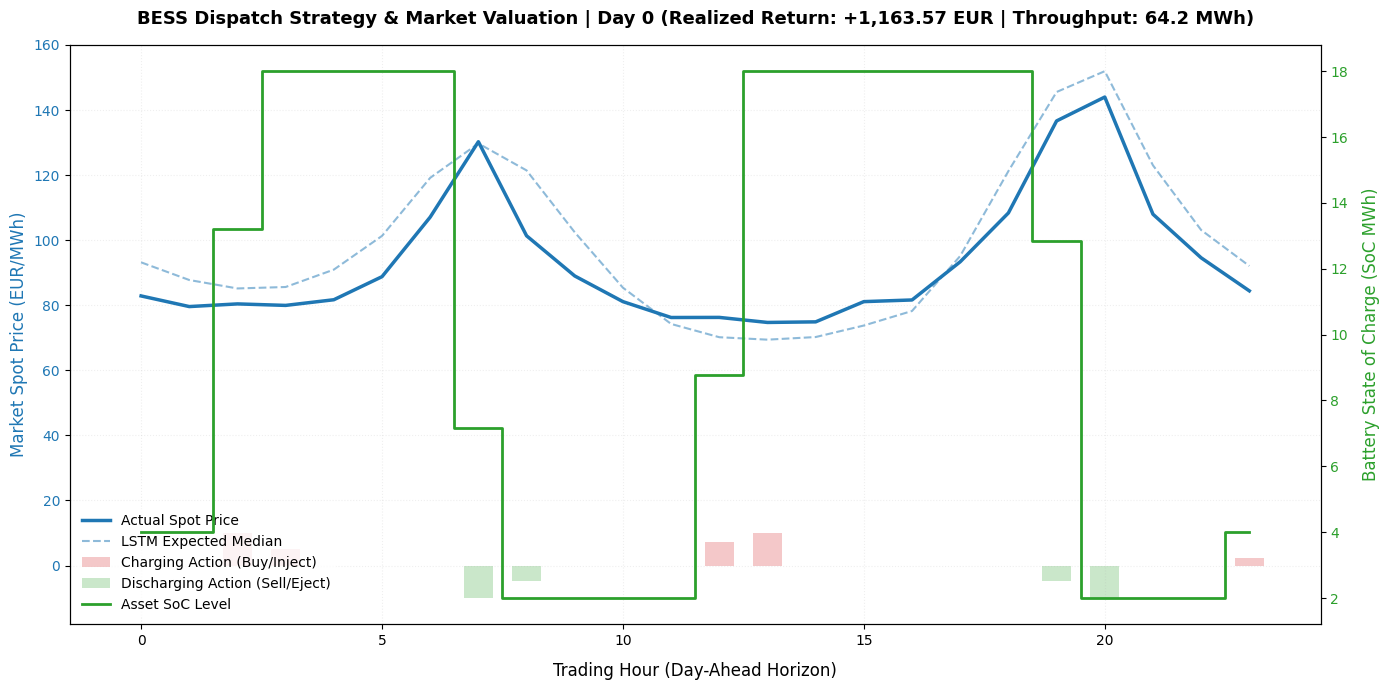

In [26]:
plot_backtest_day(df_ledger_degradation, target_day=0)

In [27]:
import torch

# Save the LSTM model (model_lstm) to a file
lstm_model_path = '../models/lstm_model.pth'
torch.save(model_lstm.state_dict(), lstm_model_path)
print(f"LSTM model saved to {lstm_model_path}")

LSTM model saved to ../models/lstm_model.pth
